In [2]:
import datetime

from numpy import load
from scipy.signal import savgol_filter
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from novami.io.file import read_pl
from novami.visualize.utils import *

from statsmodels.nonparametric.smoothers_lowess import lowess

# Figure 1: ECG and AP

✔ Matplotlib is now using: Arial


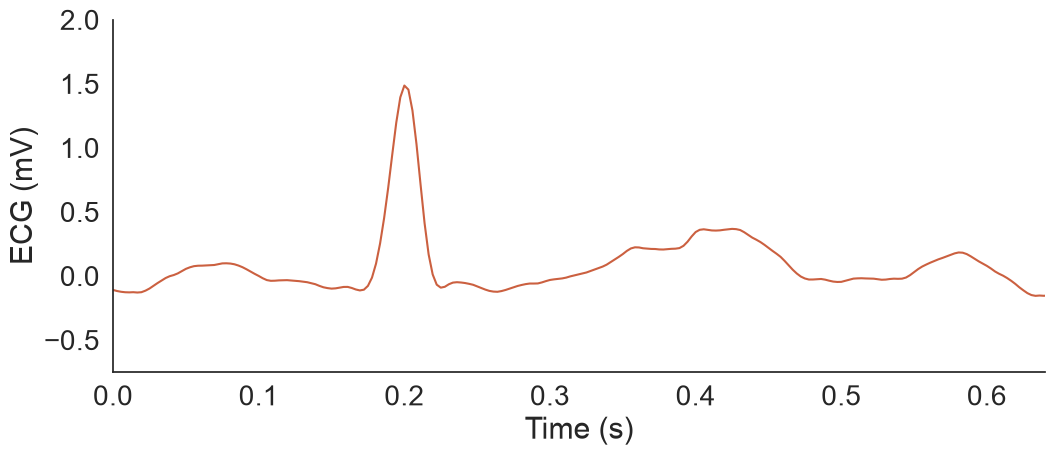

In [69]:
spp = six_point_palette()
sns.set_style('white')
sns.set_context('notebook', font_scale=1.8)
set_font()

# Data sourced from scipy.datasets.electrocardiogram and saved locally
with load('../data/ECG/ecg.dat') as file:
    ecg = file['ecg'].astype('int')

ecg = (ecg - 1024) / 200.0  # in mV

frequency = 360
time_data = np.arange(ecg.size) / frequency  # in seconds

df = pl.DataFrame({'Time': time_data, 'ECG': ecg})
df = df.filter(pl.col('Time').is_between(6.05, 6.7)).with_columns(
    (pl.col('Time') - pl.col('Time').min()).alias('Time')
)

time_arr = df['Time'].to_numpy()
ecg_arr = df['ECG'].to_numpy()

coeffs = np.polyfit(time_arr, ecg_arr, deg=1)
baseline = np.polyval(coeffs, time_arr)
ecg_detrended = ecg_arr - baseline

ecg_detrended = ecg_detrended - np.median(ecg_detrended)

WINDOW_LENGTH = 11
POLY_ORDER = 2
ecg_smooth = savgol_filter(ecg_detrended, window_length=WINDOW_LENGTH, polyorder=POLY_ORDER)

df_corrected = pl.DataFrame({
    'Time': time_arr,
    'ECG': ecg_smooth
})

g = sns.relplot(df_corrected, x='Time', y='ECG', kind='line', aspect=2.2, color=spp[-1])
g.set_axis_labels('Time (s)', 'ECG (mV)')
plt.xlim(0, 0.64)
plt.ylim(-0.75, 2)


plt.tight_layout()
plt.savefig('../figures/F1_A_ECG.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/F1_A_ECG.pdf', dpi=300, bbox_inches='tight')
plt.show()

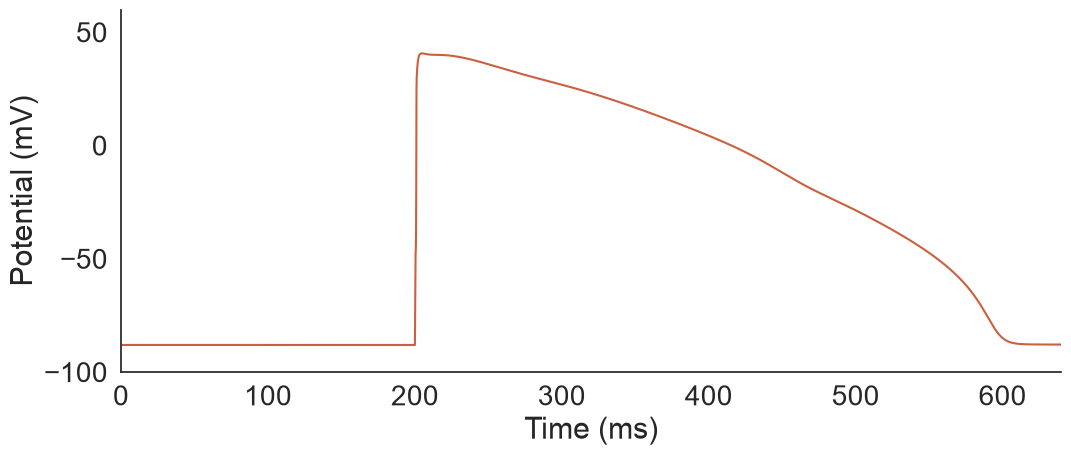

In [70]:
"""
The data used were generated using modified O'Hara-Rudy model from the CiPA initiative (without the hERG hill correction).
The model is accessible under https://github.com/FDA/CiPA
"""

aps = read_pl("../data/ECG/AP_trace_control.csv")

# Extract baseline
baseline = aps.filter(pl.col('time').is_between(1000, 1260))
baseline = baseline.with_columns(
    (pl.col('time') - 1000).alias('time')
)

# Add baseline before the actual AP
aps = aps.with_columns((pl.col('time') + 260).alias('time'))
aps = pl.concat([baseline, aps])

# Rescale to match with the ECG (values still physiological)
aps = aps.with_columns(
    (pl.col('time') / 1.3).alias('time')
)

sns.relplot(aps.filter(pl.col('time')<1000), x='time', y='v', kind='line', aspect=2.2, color=spp[-1])
plt.xlabel('Time (ms)')
plt.ylabel('Potential (mV)')
plt.xlim(0, 640)
plt.ylim(-100, 60)
plt.savefig('../figures/F1_B_AP.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/F1_B_AP.pdf', dpi=300, bbox_inches='tight')

# Figure 2: Models Performance

In [7]:
class_df = read_pl("../data/performance/classification.xlsx").filter(pl.col("Channel") != "Kv7.1")
reg_df = read_pl("../data/performance/regression.xlsx").filter(pl.col("Channel") != "Kv7.1")

In [8]:
class_df = class_df.drop(["EVL", "Splitting/Evaluation", "Model"])
class_df = class_df.unpivot(
    index = ["Study", "Eval Class", "Model Class", "Threshold", "Year", "Channel"],
    variable_name = "Metric",
    value_name = "Value"
).drop_nulls(subset="Value").to_pandas()

In [9]:
reg_df = reg_df.drop(["EVL", "Splitting/Evaluation", "Model"])

reg_df = reg_df.unpivot(
    index = ["Study", "Eval Class", "Model Class", "Year", "Channel"],
    variable_name = "Metric",
    value_name = "Value"
).drop_nulls(subset="Value").to_pandas()

In [10]:
class_df["Date"] = class_df["Year"].apply(
    lambda year: datetime.date(year=year, month=1, day=1)
)
cdf = class_df.reset_index(drop=True)

reg_df["Date"] = reg_df["Year"].apply(
    lambda year: datetime.date(year=year, month=1, day=1)
)
rdf = reg_df.reset_index(drop=True)

In [11]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.4)
set_font()

pal = six_point_palette()
df = pd.concat([cdf, rdf])

palette = {
    "hERG": pal[0],
    "Nav1.5": pal[-1],
    "Cav1.2": pal[3]
}

✔ Matplotlib is now using: Arial


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


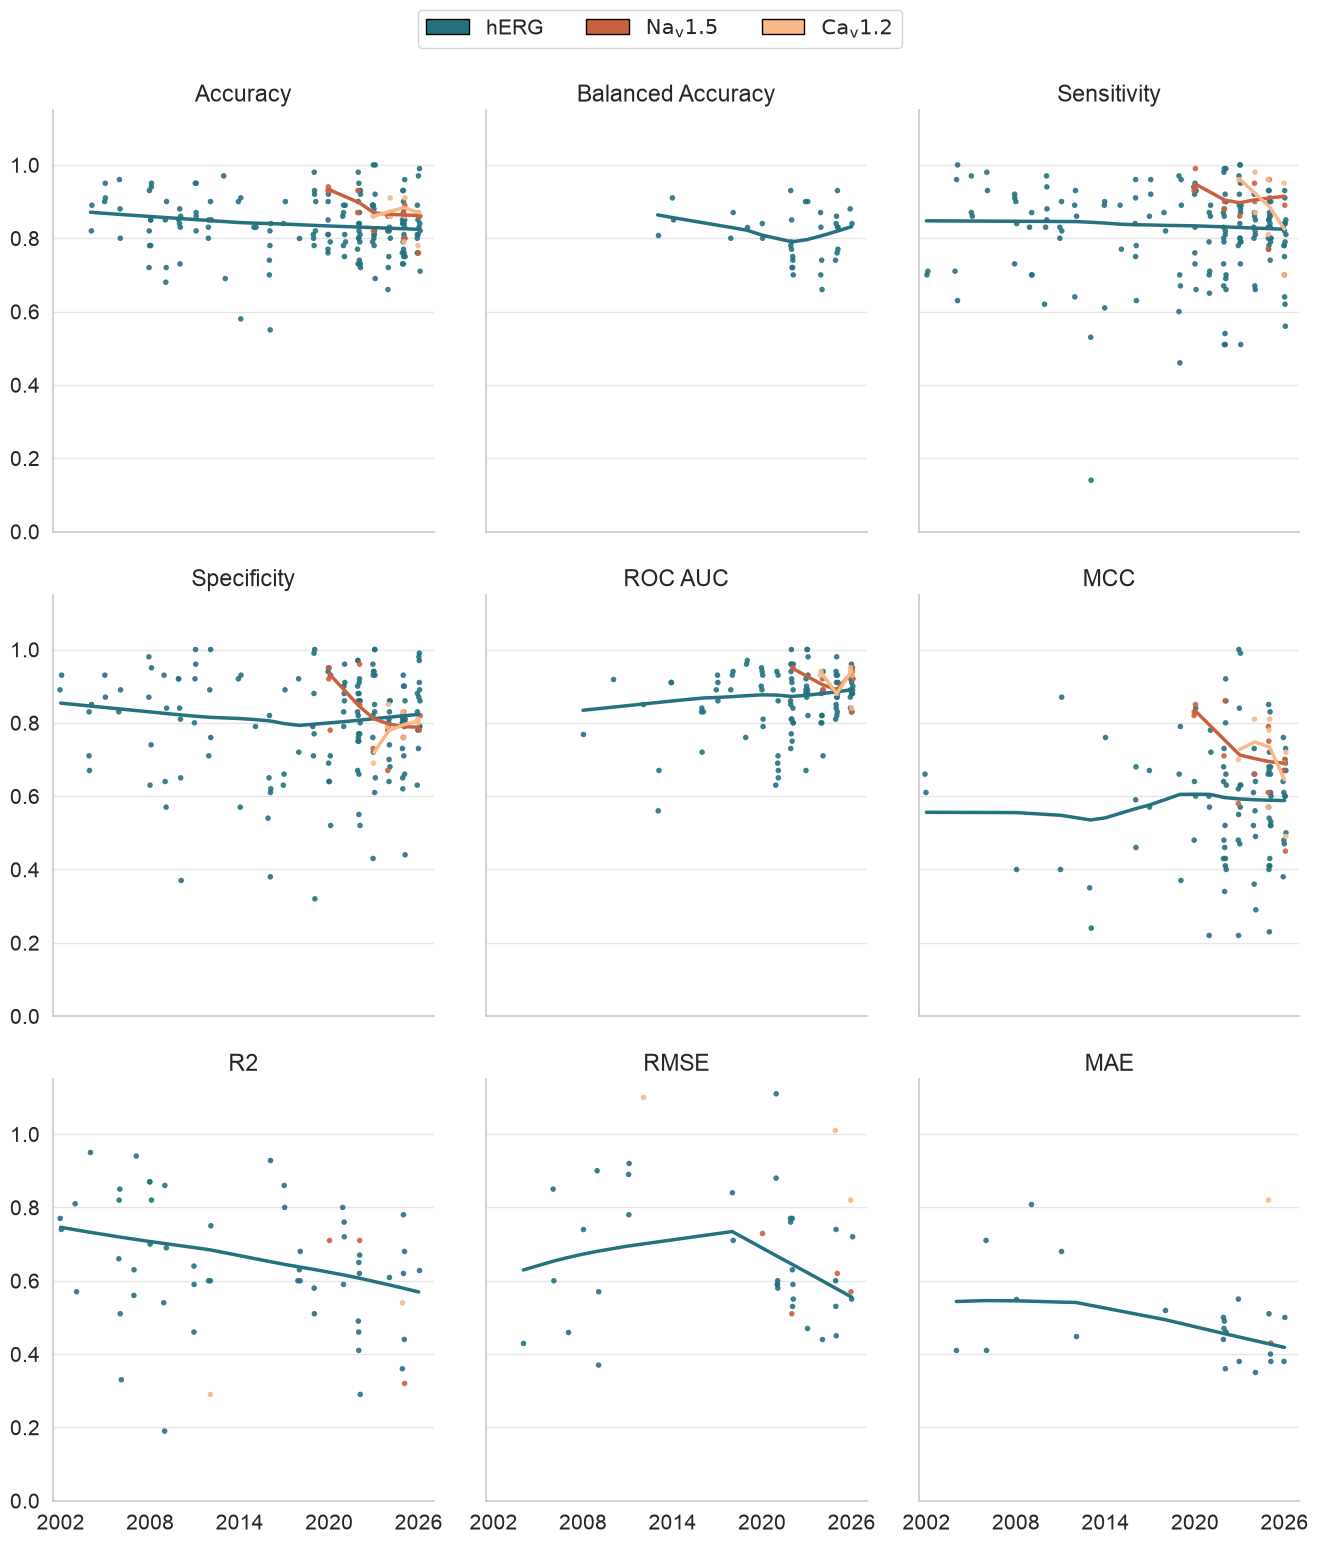

In [22]:
years_order = list(range(df["Year"].min(), df["Year"].max() + 1))
years_ticks = list(range(df["Year"].min(), df["Year"].max() + 1, 6))

metrics = {
    "ACC": "Accuracy",
    "BA": "Balanced Accuracy",
    "SEN": "Sensitivity",
    "SPE": "Specificity",
    "ROC AUC": "ROC AUC",
    "MCC": "MCC",
    "R2": "R2",
    "RMSE": "RMSE",
    "MAE": "MAE"
}

g = sns.FacetGrid(
    data=df,
    col="Metric",
    col_wrap=3,
    col_order=metrics.keys(),
    aspect=0.9,
    height=5,
)

for i, ax in enumerate(g.axes.flatten()):
    metric = ax.title.get_text().split(" = ")[-1]
    sub_df = df[df["Metric"] == metric]

    sns.stripplot(
        data=sub_df,
        x="Year",
        y="Value",
        ax=ax,
        legend=False,
        order=years_order,
        hue="Channel",
        palette=palette,
        size=4,
        alpha=0.9,
        zorder=1
    )

    for channel in ["hERG", "Nav1.5", "Cav1.2"]:
        ch_df = sub_df[sub_df["Channel"] == channel]
        col = palette.get(channel)
        if len(ch_df) >= 5:
            x_pos = ch_df["Year"].map(lambda y: years_order.index(y)).values
            y_vals = ch_df["Value"].values

            smoothed = lowess(y_vals, x_pos, frac=0.9, it=10, return_sorted=True)
            ax.plot(smoothed[:, 0], smoothed[:, 1], color=palette.get(channel), linewidth=2.5, zorder=2)


    ax.set_title(metrics.get(metric))
    ax.tick_params(axis="x", labelbottom=False)
    ax.set_xlim(-0.5, len(years_order))
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("")
    ax.set_xlabel("")

    if i + 3 >= len(g.axes):
        ax.set_xticks([years_order.index(y) for y in years_ticks])
        ax.set_xticklabels(years_ticks, rotation=0)
        ax.tick_params(axis="x", labelbottom=True)

labels = ["hERG", "Nav1.5", "Cav1.2"]
labels_f = ["hERG", r"$\mathrm{Na_v1.5}$", r"$\mathrm{Ca_v1.2}$"]
handles = [Patch(facecolor=palette.get(lab), edgecolor="black") for lab in labels]

g.figure.legend(labels=labels_f, handles=handles, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.04))

plt.tight_layout()
plt.savefig("../figures/F2_performance.png", dpi=300, bbox_inches="tight")
plt.savefig("../figures/F2_performance.eps", dpi=300, bbox_inches="tight")
plt.savefig("../figures/F2_performance.pdf", dpi=300, bbox_inches="tight")

# Figure 3: ChEMBL deposition

✔ Matplotlib is now using: Arial


/var/folders/x7/nt253mgd7cxcv4h4jqqbh32c0000gn/T/ipykernel_24696/3604452097.py:81: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 60000)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


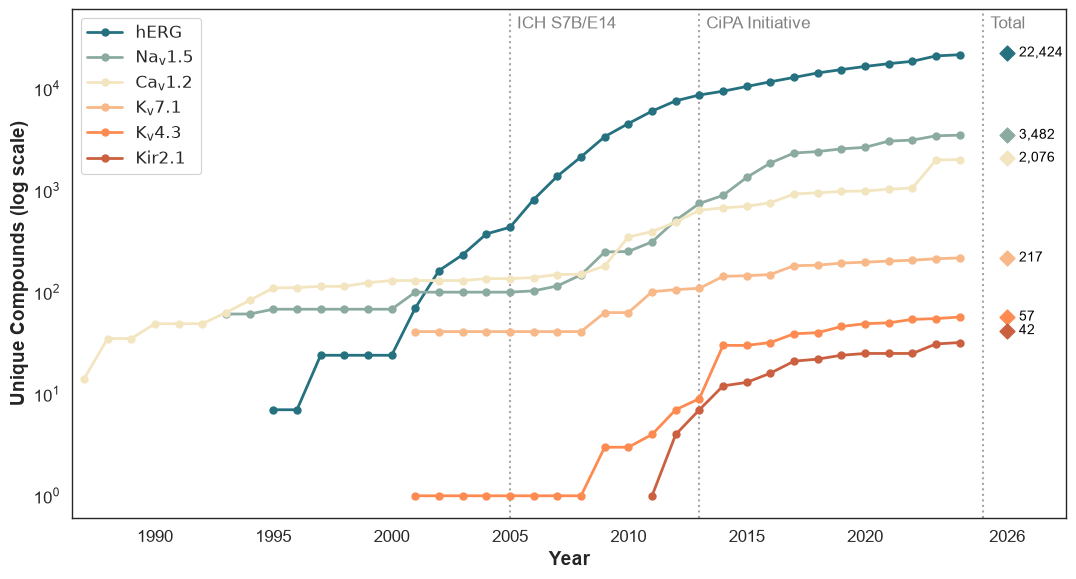

In [23]:
sns.set_style("white")
sns.set_context("paper", font_scale=1.4)
set_font()

primary_channels = ["hERG", "Nav1.5", "Cav1.2", "Kv7.1", "Kv4.3", "Kir2.1"]

channel_labels = {
    "hERG": r"$\mathrm{hERG}$",
    "Nav1.5": r"$\mathrm{Na_v1.5}$",
    "Cav1.2": r"$\mathrm{Ca_v1.2}$",
    "Kv7.1": r"$\mathrm{K_v7.1}$",
    "Kv4.3": r"$\mathrm{K_v4.3}$",
    "Kir2.1": r"$\mathrm{Kir2.1}$",
}

VLINE_YEARS = [2005, 2013, 2025]
VLINE_ANNOTATIONS = {
    2005: "ICH S7B/E14",
    2013: "CiPA Initiative",
    2025: "Total"
}

palette = six_point_palette('hex')
channel_colors = {ch: palette[i % len(palette)] for i, ch in enumerate(primary_channels)}

df = read_pl("../data/deposition/by_year.xlsx")
total = read_pl("../data/deposition/total.xlsx").with_columns(
    pl.lit(2026.0).alias("Year")
)

df = df.with_columns(
    pl.col("target_channel_name").alias("Channel")
)

total = total.with_columns(
    pl.col("target_channel_name").alias("Channel")
)

fig, ax = plt.subplots(figsize=(11, 6))

for channel in primary_channels:
    channel_data = df.filter(
        pl.col("Channel") == channel,
        pl.col("Compounds") > 0,
    ).sort("Year")

    color = channel_colors[channel]

    ax.plot(
        channel_data["Year"],
        channel_data["Compounds"],
        color=color,
        linewidth=2,
        marker="o",
        markersize=5,
        label=channel_labels[channel],
    )

    x_last = channel_data["Year"][-1]
    y_last = channel_data["Compounds"][-1]

    y_total = total.filter(pl.col("Channel") == channel)["Compounds"][0]

    ax.scatter(2026, y_total, color=color, marker="D", s=60, zorder=5)

    ax.text(
        2026.5, y_total,
        f"{y_total:,}",
        color="black",
        fontsize=10,
        va="center",
        ha="left",
    )

plt.yscale("log")
ax.set_xlabel("Year", fontweight="bold")
ax.set_ylabel("Unique Compounds (log scale)", fontweight="bold")
ax.legend(loc="upper left", framealpha=0.9)

plt.xlim(1986.5, 2028.5)
plt.ylim(0, 60000)

for year in VLINE_YEARS:
    ax.axvline(x=year, color="gray", linestyle=":", linewidth=1.5, alpha=0.7, zorder=1)
    ax.annotate(
        VLINE_ANNOTATIONS[year],
        xy=(year, ax.get_ylim()[1]),
        xytext=(5, -5),
        textcoords="offset points",
        fontsize=12,
        color="gray",
        ha="left",
        va="top",
    )

xticks = list(range(1990, 2025, 5)) + [2026]
xticklabels = [str(y) for y in range(1990, 2025, 5)] + ["2026"]
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)

plt.tight_layout()
plt.savefig("../figures/F3_ChEMBL_deposition_compounds.png", dpi=300, bbox_inches="tight")
plt.savefig("../figures/F3_ChEMBL_deposition_compounds.eps", dpi=300, bbox_inches="tight")
plt.savefig("../figures/F3_ChEMBL_deposition_compounds.pdf", dpi=300, bbox_inches="tight")
plt.show()

# ToC components

In [13]:
df = read_pl("../data/supporting_tables/s1.xlsx")

In [16]:
chan_map = {
    'Kv7.1': 'Non-hERG',
    'hERG, Nav1.5': 'Multi-channel',
    'Nav1.5': 'Non-hERG',
    'hERG, Nav1.5, Cav1.2': 'Multi-channel',
    'hERG, Kv7.1': 'Multi-channel',
    'hERG': 'hERG',
    'hERG, NaV1.5, CaV1.2': 'Multi-channel',
    'Cav1.2': 'Non-hERG',
    'ERG, Nav1.5, Cav1.2': 'Multi-channel',
    "hERG, Nav1.5, Cav1.2, Kv7.1": "Multi-channel",
}

df = df.with_columns(
    pl.col("Channel").map_elements(
        lambda chan: chan_map.get(chan),
        return_dtype=pl.String
    ).alias("Study Type")
)

In [17]:
df = df.with_columns(
    pl.when(
        pl.col("Year") <= 2008
    ).then(pl.lit("Foundation\n(2001-2008)"))
    .when(
        pl.col("Year") <= 2018
    ).then(pl.lit("Consolidation\n(2009-2018)"))
    .otherwise(
        pl.lit("Expansion\n(2019-2026)")
    ).alias("Period")
)

pdf = df.group_by(["Period", "Study Type"]).agg(
    pl.len().alias("No Studies")
)
pdf = pdf.to_pandas()

period_dtype = pd.CategoricalDtype(["Foundation\n(2001-2008)", "Consolidation\n(2009-2018)", "Expansion\n(2019-2026)"], ordered=True)
study_dtype = pd.CategoricalDtype(["Non-hERG", "Multi-channel", "hERG"], ordered=True)

pdf = pdf.astype({
    "Period": period_dtype,
    "Study Type": study_dtype
})

✔ Matplotlib is now using: Arial


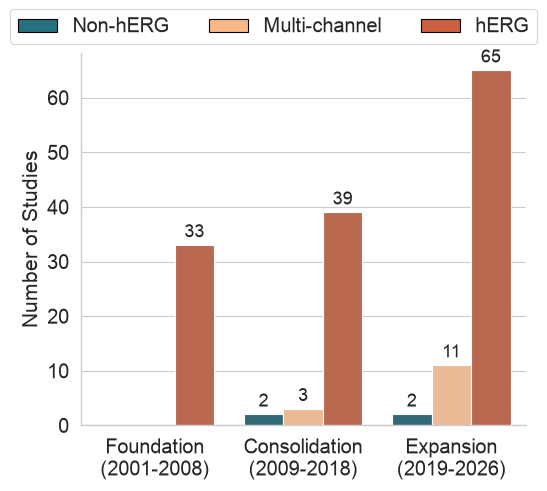

In [18]:
pal = six_point_palette()

study_palette = {
    "Non-hERG": pal[0],
    "Multi-channel": pal[3],
    "hERG": pal[-1]
}

sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.6)
set_font()

g = sns.catplot(pdf, x="Period", y="No Studies", kind='bar', hue="Study Type", legend=False, aspect=1.1, palette=study_palette)
plt.xlabel("")

labels = ["Non-hERG", "Multi-channel", "hERG"]
handles = [Patch(label=label, edgecolor="black", facecolor=study_palette.get(label)) for label in labels]
plt.legend(labels=labels, handles=handles, ncols=3, loc="upper center", bbox_to_anchor=(0.5, 1.06), bbox_transform=g.figure.transFigure)
plt.ylabel("Number of Studies")

ax = g.ax

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{int(v)}" if v > 0 else "" for v in container.datavalues],
        padding=3,
        fontsize=13
    )

g.figure.savefig(
    "../figures/study_types_by_period.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=1200
)